# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from wordcloud import WordCloud
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from folium.plugins import FastMarkerCluster
from sklearn.metrics import confusion_matrix, classification_report



# What is Zomato? 
Zomato is a leading Indian technology company and platform connecting customers, restaurant partners, and delivery partners. 
Primarily used for searching, reviewing, and ordering food online.

# Loading CSV file

In [2]:
# load dataframe via pandas
df = pd.read_csv('/kaggle/input/datasets/shrutimehta/zomato-restaurants-data/zomato.csv', encoding = 'latin-1') # encoding is 'latin-1' because of the way the data was collected


# What does the data look like?

In [3]:
# data types of columns, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [4]:
# checking first 2 rows of the data
df.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


# Explaratory Data Analysis (EDA)

In [5]:
# descriptive statistics of data
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [6]:
# creating another data frame to get country codes and names according to zomato records
df_country_names = pd.read_excel('/kaggle/input/datasets/shrutimehta/zomato-restaurants-data/Country-Code.xlsx')

In [7]:
df_country_names

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


In [8]:
# merging both data frames to get country names

df = pd.merge(
    df, 
    df_country_names[['Country Code', 'Country']],
    on = 'Country Code',
    how = 'left'
)

In [9]:
# now we have both country code and according country name
df.head(1)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines


# Which countries have the most restaurants in records?

In [10]:
country_names = df.Country.value_counts().index
country_names


Index(['India', 'United States', 'United Kingdom', 'Brazil', 'South Africa',
       'UAE', 'New Zealand', 'Turkey', 'Australia', 'Phillipines', 'Indonesia',
       'Qatar', 'Singapore', 'Sri Lanka', 'Canada'],
      dtype='object', name='Country')

In [11]:
country_counts = df.Country.value_counts().values
country_counts

array([8652,  434,   80,   60,   60,   60,   40,   34,   24,   22,   21,
         20,   20,   20,    4])

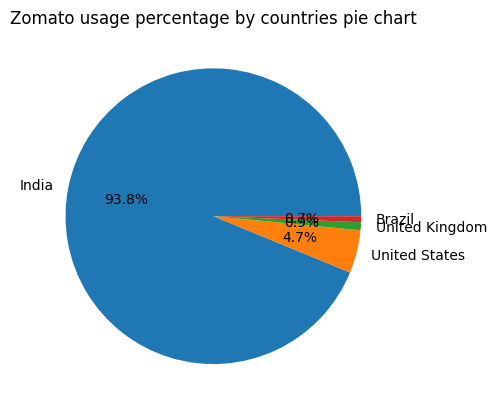

In [12]:
plt.pie(country_counts[:4],
        labels = country_names[:4],
       autopct='%1.1f%%')
plt.title('Zomato usage percentage by countries pie chart')
plt.show()


# What do restaurant ratings look like?

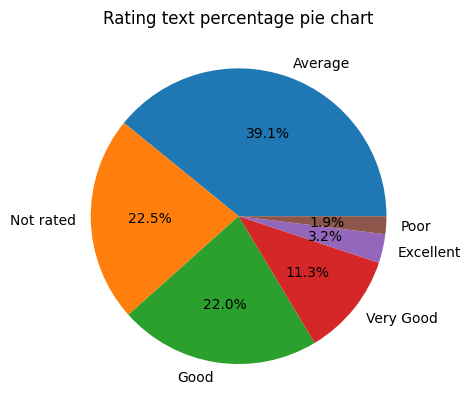

In [13]:
plt.pie(df['Rating text'].value_counts().values,
         labels = df['Rating text'].value_counts().index,
         autopct = '%1.1f%%')
plt.title('Rating text percentage pie chart')
plt.show()

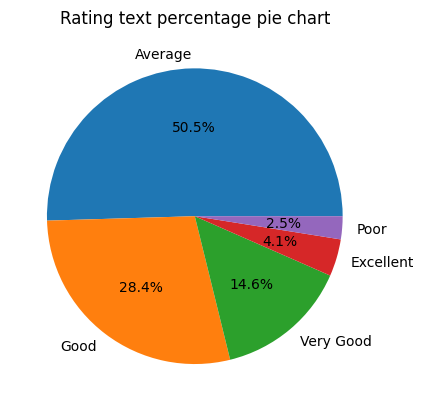

In [14]:
df = df[~(df['Rating text'] == 'Not rated')]
plt.pie(df['Rating text'].value_counts().values,
         labels = df['Rating text'].value_counts().index,
         autopct = '%1.1f%%')
plt.title('Rating text percentage pie chart')
plt.show()

We remove restaurants with 'not rated' values

# Rating frequency histogram

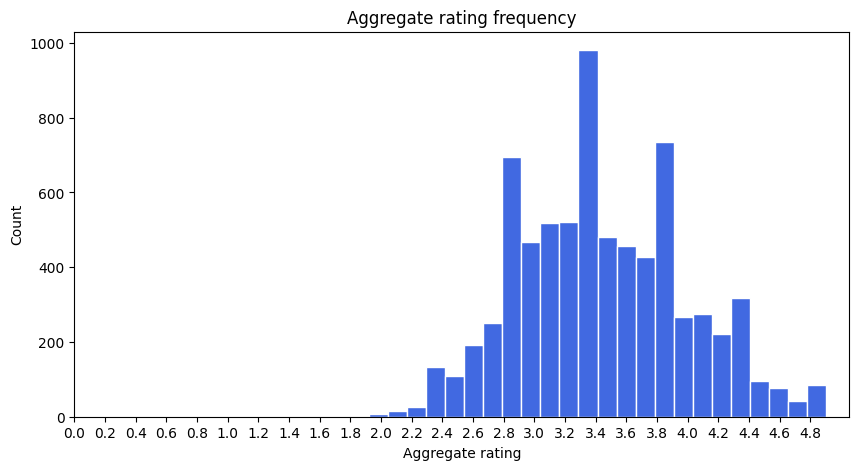

In [15]:
# Rating frequency
plt.figure(figsize=(10, 5))
plt.hist(df['Aggregate rating'], bins = 25, color = 'royalblue', edgecolor = 'white')
plt.title('Aggregate rating frequency')
plt.xlabel('Aggregate rating')
plt.ylabel('Count')
plt.xticks(np.arange(0, 5, 0.2))
plt.show()


# Word Cloud for Cities by their frequency

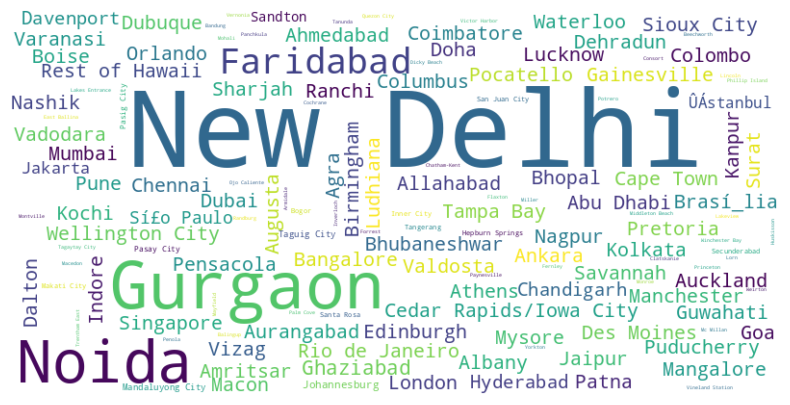

In [16]:
# Generating word cloud for cities

city_counts = df['City'].value_counts().to_dict()

wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(city_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# Word Cloud for Cuisines 

Some values reapper due to multiple cuisines in a restaurant

In [17]:
cuisine_counts = df['Cuisines'].str.split(",").explode().value_counts().to_dict()

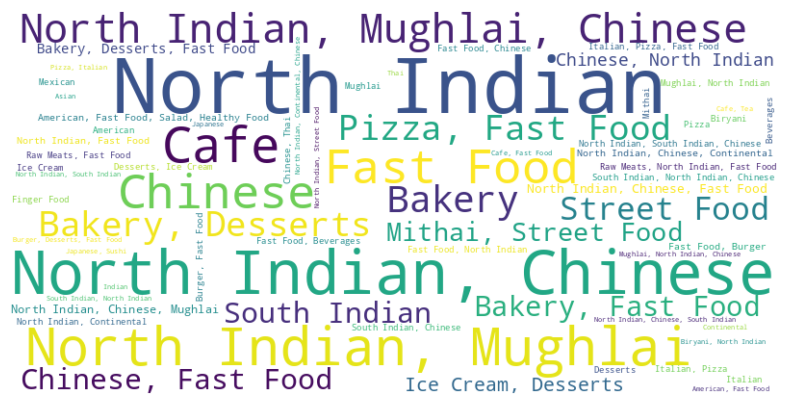

In [18]:
# Generating word cloud for cuisines

cuisine_counts = df['Cuisines'].value_counts().to_dict()

wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(cuisine_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# Class prediction Model Preparation

# Manipulating data
Changing from 'Yes' and 'No' to 1,0 values
We're also going to be using Votes in predictions, but it's safer to use them in a log function for more balanced decision making

In [19]:
df['Has Table booking'] = df['Has Table booking'].map({'Yes':1, 'No': 0})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes':1, 'No': 0})
df['Is delivering now'] = df['Is delivering now'].map({'Yes':1, 'No': 0})
df['Switch to order menu'] = df['Switch to order menu'].map({'Yes':1, 'No': 0})
df['Log_Votes'] = np.log1p(df['Votes'])


# Selecting features for the model

We're creating a top_10 cuisines list for feautures, to see if cuisine makes a difference in predictions

In [20]:
all_cuisines = df['Cuisines'].str.split(', ').explode()
top_10_cuisines = all_cuisines.value_counts().head(10).index.tolist()
for cuisine in top_10_cuisines:
    df[cuisine] = df['Cuisines'].apply(lambda x: 1 if isinstance(x,str) and cuisine in x else 0)

In [21]:
# Since the mean rating is near 3.44, we decided that a successful business should have at least 3.5 rating
df['Is_Successful'] = (df['Aggregate rating'] >= 3.5).astype(int)

# Creating a Random Forest Classifier model

With these features we will try to predict if a business is succesful (has equal to or greater than 3.5 rating )

In [22]:

features = ['Price range', 'Has Table booking', 'Has Online delivery','Is delivering now', 'Log_Votes'] + top_10_cuisines

X = df[features]
y = df['Is_Successful']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 )

model = RandomForestClassifier(n_estimators = 100)
model.fit(X_train, y_train)

RandomForestClassifier()

# Feature importance

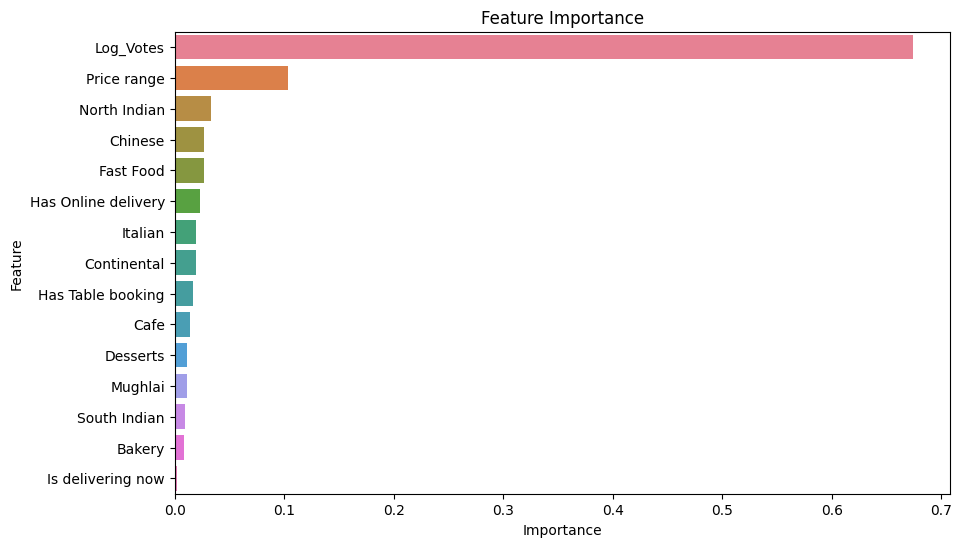

In [23]:
importances = model.feature_importances_

feature_results = pd.DataFrame({'Feature': features, 'Importance' : importances})

feature_results = feature_results.sort_values(by='Importance', ascending = False)

plt.figure(figsize=(10,6))
sns.barplot(x = 'Importance', y = 'Feature', data = feature_results, hue='Feature', legend = False)
plt.title('Feature Importance')
plt.show()

Normally we shouldn't have votes column in feature importance, but people vote more on restaurants they love and hate, so it could be a factor in predicting their ratings

# Confusion Matrix



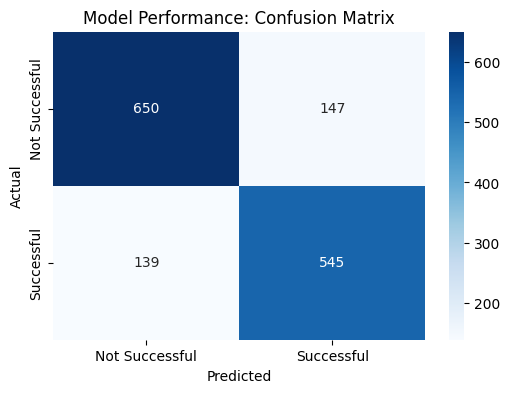

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       797
           1       0.79      0.80      0.79       684

    accuracy                           0.81      1481
   macro avg       0.81      0.81      0.81      1481
weighted avg       0.81      0.81      0.81      1481



In [24]:

# Use model to make predictions on the test set
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

# Seaborn plot 
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Successful', 'Successful'], 
            yticklabels=['Not Successful', 'Successful'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Performance: Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

# Sample Map

We use folium to map the restaurants' locations using their coordinates. Sample size of 2000 is used with clustering to avoid performance issues.

In [25]:

df_map_clean = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]
map_data = df_map_clean[['Latitude', 'Longitude', 'Restaurant Name']].sample(n=2000).values.tolist()

map_fast = folium.Map(location=[df_map_clean['Latitude'].mean(), df_map_clean['Longitude'].mean()], zoom_start=2)

callback = """
    function (row) {
        var marker = L.marker(new L.LatLng(row[0], row[1]));
        marker.bindPopup(row[2]);
        return marker;
    };
"""

FastMarkerCluster(data=map_data, callback=callback).add_to(map_fast)

map_fast

# Top 10 Restaurants

Deciding top 10 restaurants, according to ratings, log(vote count) and price range, sadly we don't have actual customer numbers or profits so we have to "hard code" success parameters subjectively

In [26]:


df_analysis = df[(df['Latitude'] != 0) & (df['Aggregate rating'] > 0 )].copy()

scaler = MinMaxScaler()
df_analysis['norm_rating'] = scaler.fit_transform(df_analysis[['Aggregate rating']])
df_analysis['norm_votes'] = scaler.fit_transform(df_analysis[['Log_Votes']])
df_analysis['norm_price'] = 1 - scaler.fit_transform(df_analysis[['Average Cost for two']])

df_analysis['Best_Value_Score'] = (
    (df_analysis['norm_rating'] * 0.6) + (df_analysis['norm_votes'] * 0.2) + ( df_analysis['norm_price'] * 0.2 )
)

top_10 = df_analysis.sort_values(by='Best_Value_Score', ascending = False).head(10)

print("Top 10 Best Value Restaurants")
print(top_10[['Restaurant Name', 'City', 'Aggregate rating', 'Votes', 'Average Cost for two']])



Top 10 Best Value Restaurants
                          Restaurant Name       City  Aggregate rating  Votes  \
2414                      Barbeque Nation    Kolkata               4.9   5966   
2307            AB's - Absolute Barbecues  Hyderabad               4.9   5434   
728                                  Toit  Bangalore               4.8  10934   
2495                      Mirchi And Mime     Mumbai               4.9   3244   
3013                   Naturals Ice Cream  New Delhi               4.9   2620   
374         McGuire's Irish Pub & Brewery  Pensacola               4.9   2238   
735                              Truffles  Bangalore               4.7   9667   
3601            Indian Accent - The Manor  New Delhi               4.9   1934   
2409                      Barbeque Nation    Kolkata               4.9   1753   
362   Pom Pom's Teahouse and Sandwicheria    Orlando               4.9   1457   

      Average Cost for two  
2414                  1600  
2307                

# Top 10 Map

In [27]:
top_10_lat = top_10.iloc[0]['Latitude']
top_10_lon = top_10.iloc[0]['Longitude']
top_10_map = folium.Map(location = [top_10_lat,top_10_lon], zoom_start = 4)

for index, row in top_10.iterrows():
    folium.Marker(
        location = [row['Latitude'], row['Longitude']], 
        popup = f"Name: {row['Restaurant Name']}<br>Rating: {row['Aggregate rating']}<br>Price: {row['Average Cost for two']}",
        icon = folium.Icon(color = 'orange', icon = 'star')
    ).add_to(top_10_map) 

top_10_map

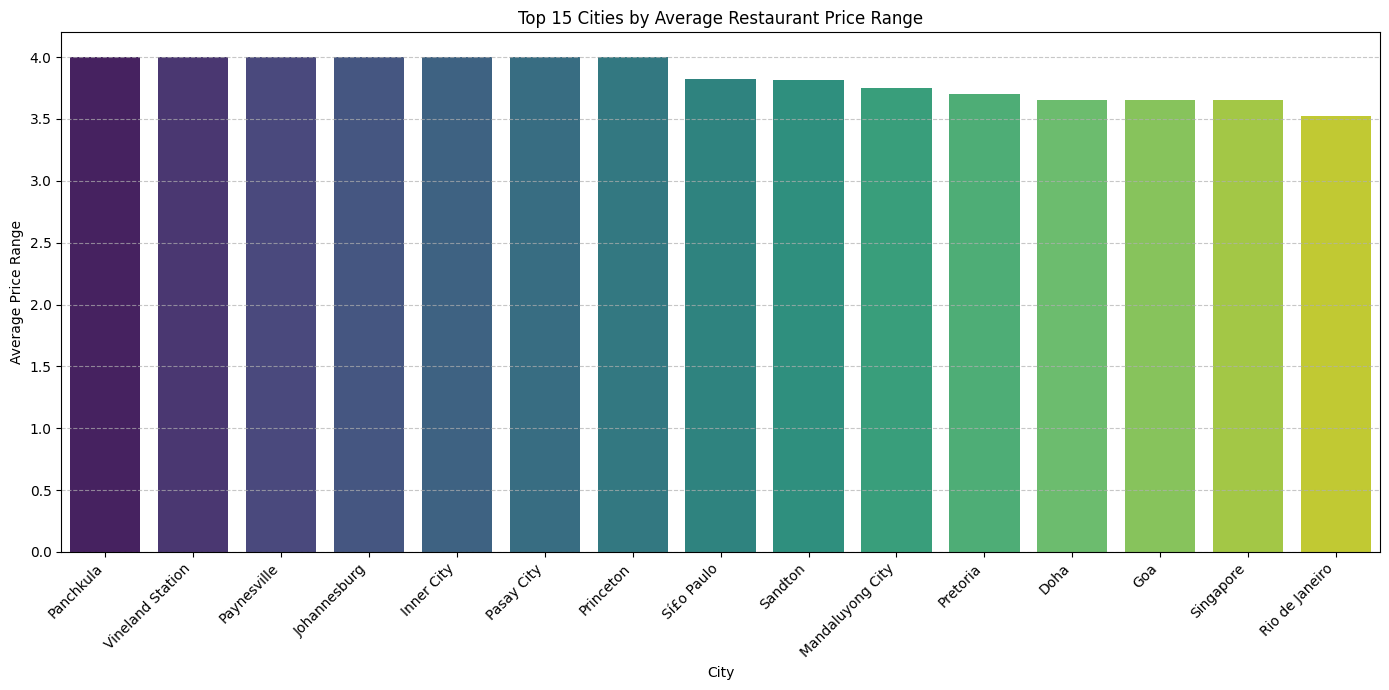

In [28]:
# calculate average price range by city
avg_price_range_by_city = df.groupby('City')['Price range'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14,7))
sns.barplot(x='City', y='Price range', data=avg_price_range_by_city.head(15), palette='viridis', hue='City', legend = False)
plt.title('Top 15 Cities by Average Restaurant Price Range')
plt.xlabel('City')
plt.ylabel('Average Price Range')
plt.xticks(rotation=45, ha = 'right')
plt.grid(axis = 'y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

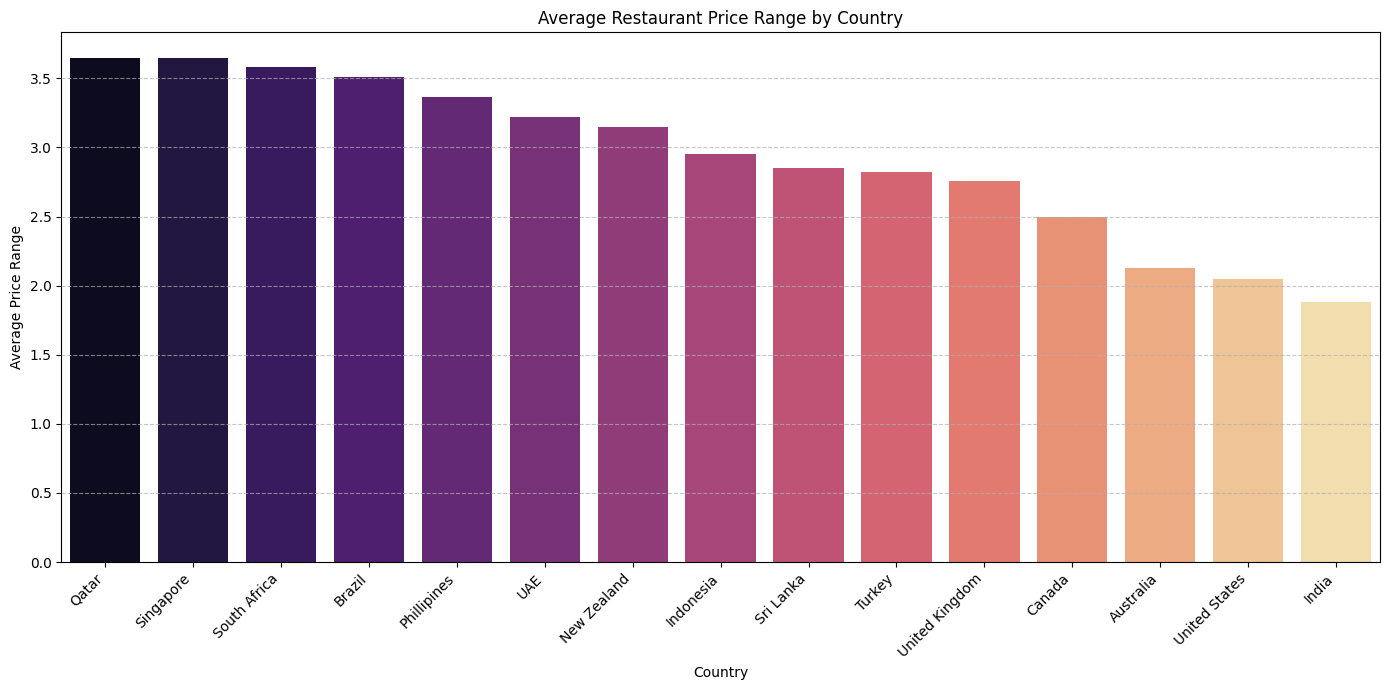

In [29]:
# Calculate average price range by country
avg_price_range_by_country = df.groupby('Country')['Price range'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Country', y='Price range', data=avg_price_range_by_country, palette='magma', hue='Country', legend=False)
plt.title('Average Restaurant Price Range by Country')
plt.xlabel('Country')
plt.ylabel('Average Price Range')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
from folium.plugins import HeatMap

df_heatmap_data = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()

# preparing data for heatmap plugin: [latitude, longitude, weight(Price range)]
# using 'price range' directly as  the weight for the heatmap

heatmap_data = df_heatmap_data[['Latitude', 'Longitude', 'Price range']].values.tolist()

# create base map centered at mean coordinates

mean_lat = df_heatmap_data['Latitude'].mean()
mean_lon = df_heatmap_data['Longitude'].mean()
heatmap_map = folium.Map(location =[mean_lat, mean_lon], zoom_start = 2)

# add heatmap layer to map
HeatMap(heatmap_data, radius = 10, blur = 15, min_opacity=0.5).add_to(heatmap_map)


heatmap_map
